In [12]:
import requests
import pandas as pd
import numpy as np

url = "http://localhost/Chronology/fetch_data.php"
res = requests.get(url)
data = res.json()

df = pd.DataFrame(data)
df.columns = df.columns.str.lower()

df = df.rename(columns={
    "time": "crime_time",
    "crime_time": "crime_time"
})

print(df.head())

    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November  2025   05:00:00  07:00:00   

   location crime_type crime_count  
0     murud   accident           2  
1     mahad     murder           8  
2     mahad   accident           4  
3    alibag      theft           8  
4  Revdanda    Robbery           3  


In [14]:
df['start_time'] = df['start_time'].astype(str)

df['hour'] = df['start_time'].str.split(":").str[0]
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

df = df.dropna(subset=['hour'])
df['hour'] = df['hour'].astype(int)

In [24]:
X = df[['hour']].values

X = X + np.random.normal(0, 3, size=X.shape)

y = []

for h in df['hour']:

    if 0 <= h < 6:
        prob = 0.65
    elif 6 <= h < 12:
        prob = 0.35
    elif 12 <= h < 18:
        prob = 0.45
    else:
        prob = 0.75

    y.append(np.random.choice([0,1], p=[1-prob, prob]))

y = np.array(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [17]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}


Logistic Regression
Accuracy  : 57.50%
Precision : 59.15%
Recall    : 65.62%
F1 Score  : 62.22%

2x2 Confusion Matrix:
[[27 29]
 [22 42]]
TN:27 FP:29 FN:22 TP:42


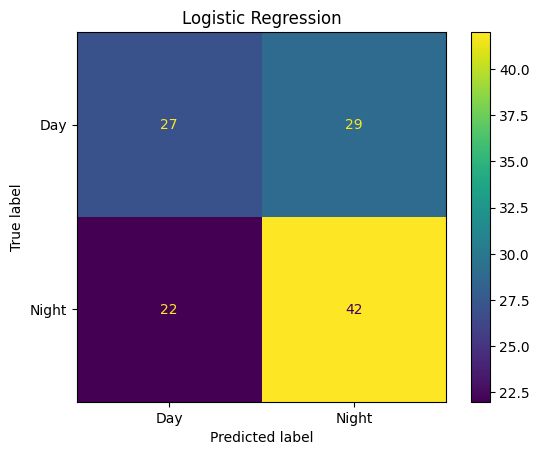


Decision Tree
Accuracy  : 54.17%
Precision : 62.86%
Recall    : 34.38%
F1 Score  : 44.44%

2x2 Confusion Matrix:
[[43 13]
 [42 22]]
TN:43 FP:13 FN:42 TP:22


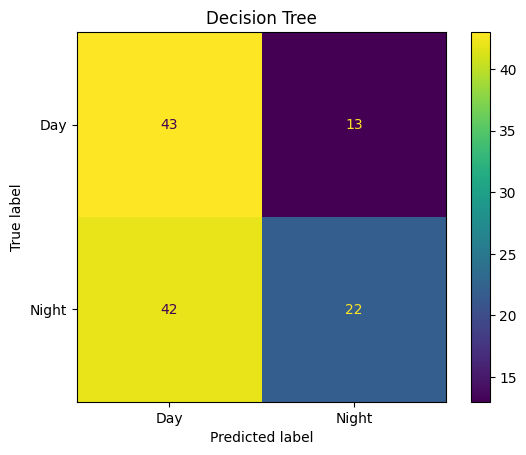


Random Forest
Accuracy  : 51.67%
Precision : 54.29%
Recall    : 59.38%
F1 Score  : 56.72%

2x2 Confusion Matrix:
[[24 32]
 [26 38]]
TN:24 FP:32 FN:26 TP:38


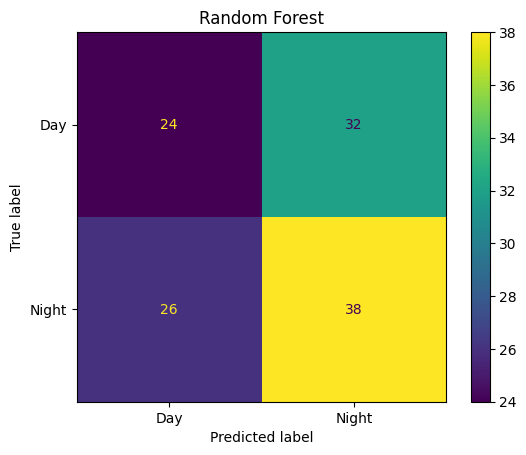


KNN
Accuracy  : 58.33%
Precision : 60.61%
Recall    : 62.50%
F1 Score  : 61.54%

2x2 Confusion Matrix:
[[30 26]
 [24 40]]
TN:30 FP:26 FN:24 TP:40


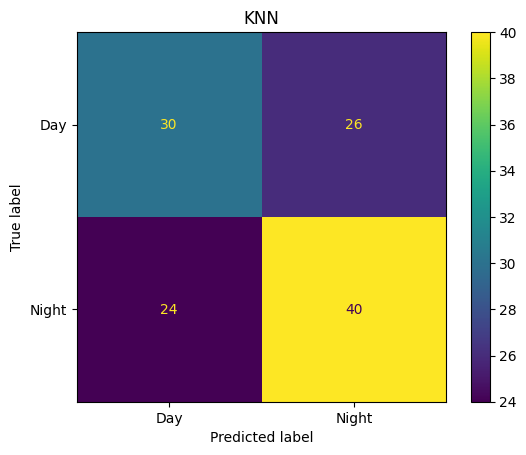


SVM
Accuracy  : 60.83%
Precision : 65.45%
Recall    : 56.25%
F1 Score  : 60.50%

2x2 Confusion Matrix:
[[37 19]
 [28 36]]
TN:37 FP:19 FN:28 TP:36


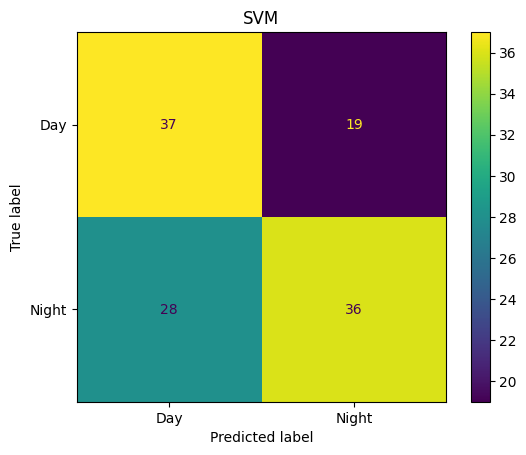

In [18]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred) * 100
    prec = precision_score(y_test, pred, zero_division=0) * 100
    rec = recall_score(y_test, pred, zero_division=0) * 100
    f1 = f1_score(y_test, pred, zero_division=0) * 100

    results.append([name, acc, prec, rec, f1])

    print("\n======================")
    print(name)
    print("======================")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1 Score  : {f1:.2f}%")

    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    print("\n2x2 Confusion Matrix:")
    print(cm)

    print(f"TN:{tn} FP:{fp} FN:{fn} TP:{tp}")

    ConfusionMatrixDisplay(cm, display_labels=["Day","Night"]).plot()
    plt.title(name)
    plt.show()

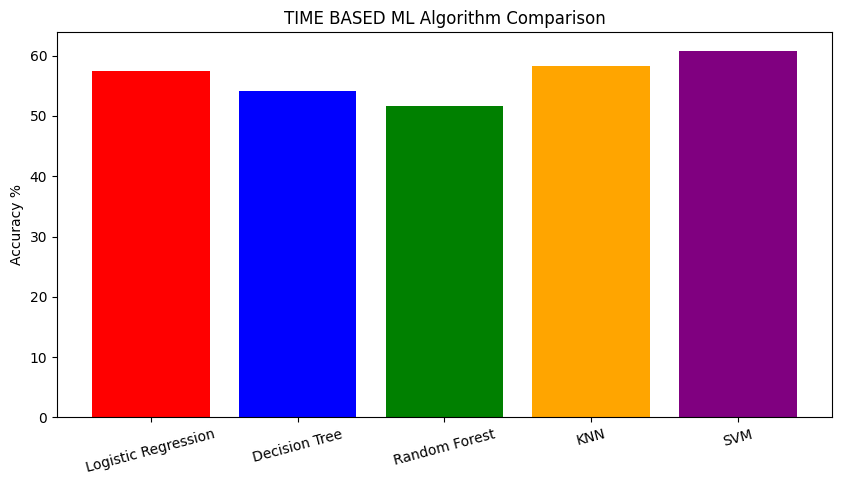

In [19]:
algos = [r[0] for r in results]
acc = [r[1] for r in results]

plt.figure(figsize=(10,5))
plt.bar(algos, acc, color=['red','blue','green','orange','purple'])

plt.title("TIME BASED ML Algorithm Comparison")
plt.ylabel("Accuracy %")
plt.xticks(rotation=15)

plt.show()

In [23]:
ranking = sorted(results, key=lambda x: x[1], reverse=True)

print("====================================")
print("FINAL TIME-BASED MODEL COMPARISON")
print("====================================\n")

print(f"{'Rank':<5}{'Algorithm':<25}{'Accuracy (%)':<15}")
print("-"*50)

for i, r in enumerate(ranking, 1):
    print(f"{i:<5}{r[0]:<25}{r[1]:<15.2f}")

print("\n====================================")
print("BEST PERFORMING ALGORITHM")
print(f"{ranking[0][0]} → {ranking[0][1]:.2f}% Accuracy")

FINAL TIME-BASED MODEL COMPARISON

Rank Algorithm                Accuracy (%)   
--------------------------------------------------
1    SVM                      60.83          
2    KNN                      58.33          
3    Logistic Regression      57.50          
4    Decision Tree            54.17          
5    Random Forest            51.67          

BEST PERFORMING ALGORITHM
SVM → 60.83% Accuracy
